In [2]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,classification_report,roc_auc_score
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from tpot import TPOTClassifier





In [3]:
data_path = "Cancer_Data.csv"
df = pd.read_csv(data_path)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [6]:
df['radius_se'].value_counts()


radius_se
0.2860    3
0.2204    3
0.2684    2
0.2239    2
0.1601    2
         ..
0.6298    1
0.8361    1
0.2889    1
0.1731    1
0.3857    1
Name: count, Length: 540, dtype: int64

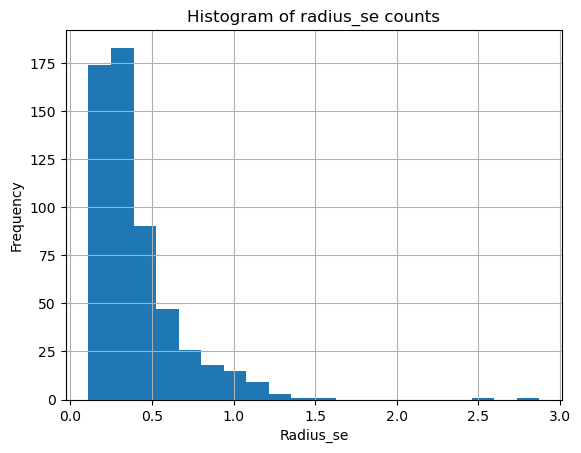

In [7]:
import matplotlib.pyplot as plt
df['radius_se'].hist(bins=20)
plt.xlabel('Radius_se')
plt.ylabel('Frequency')
plt.title('Histogram of radius_se counts')
plt.show()

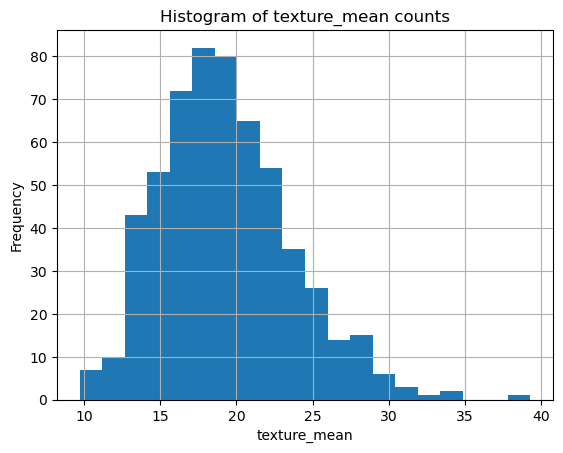

In [8]:
import matplotlib.pyplot as plt

df['texture_mean'].hist(bins=20)
plt.xlabel('texture_mean')   # This should work
plt.ylabel('Frequency')
plt.title('Histogram of texture_mean counts')
plt.show()



In [9]:
df['diagnosis']=df['diagnosis'].map({'M':1,'B':0})

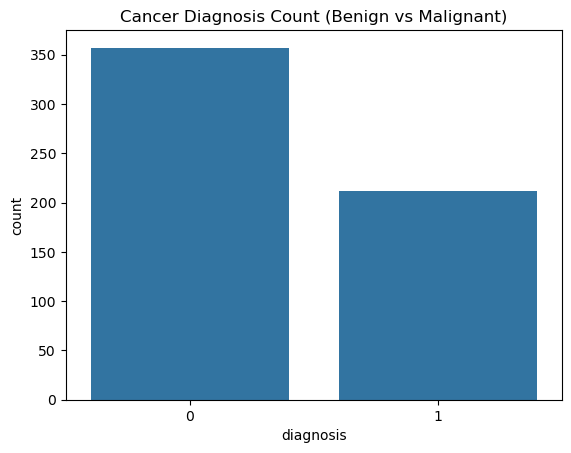

In [10]:
sns.countplot(x='diagnosis',data=df)
plt.title("Cancer Diagnosis Count (Benign vs Malignant)")
plt.show()


In [11]:
df=df.drop(columns=['Unnamed: 32'])

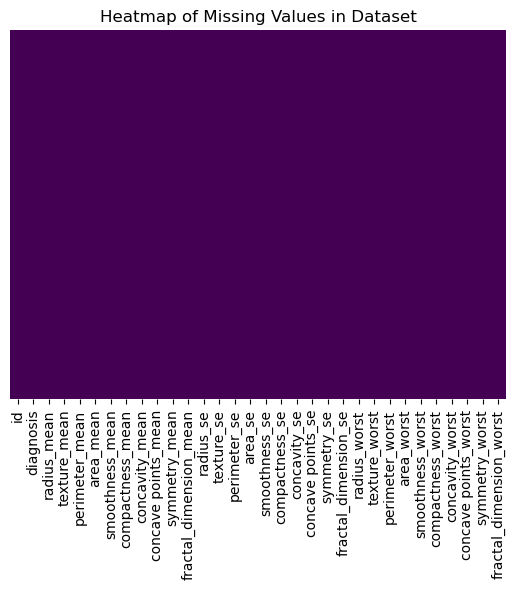

In [12]:
import seaborn as sns
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)


plt.title('Heatmap of Missing Values in Dataset')
plt.show()

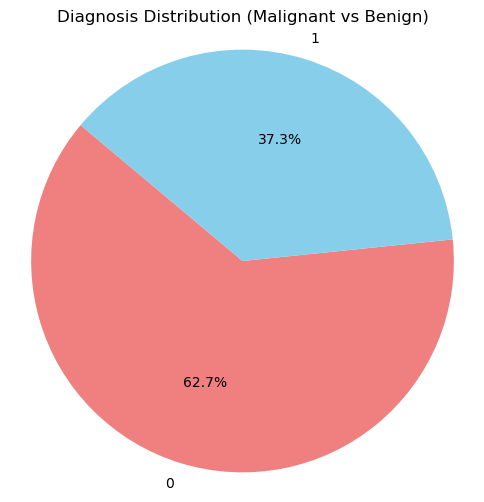

In [13]:

diagnosis_counts = df['diagnosis'].value_counts()


plt.figure(figsize=(6,6))
plt.pie(diagnosis_counts, labels=diagnosis_counts.index, autopct='%1.1f%%', startangle=140, colors=['lightcoral', 'skyblue'])
plt.title("Diagnosis Distribution (Malignant vs Benign)")
plt.axis('equal')
plt.savefig("Pie chart.png", dpi=300, bbox_inches='tight')
plt.show()


In [14]:
print(df['diagnosis'].value_counts(normalize=True) * 100)

diagnosis
0    62.741652
1    37.258348
Name: proportion, dtype: float64


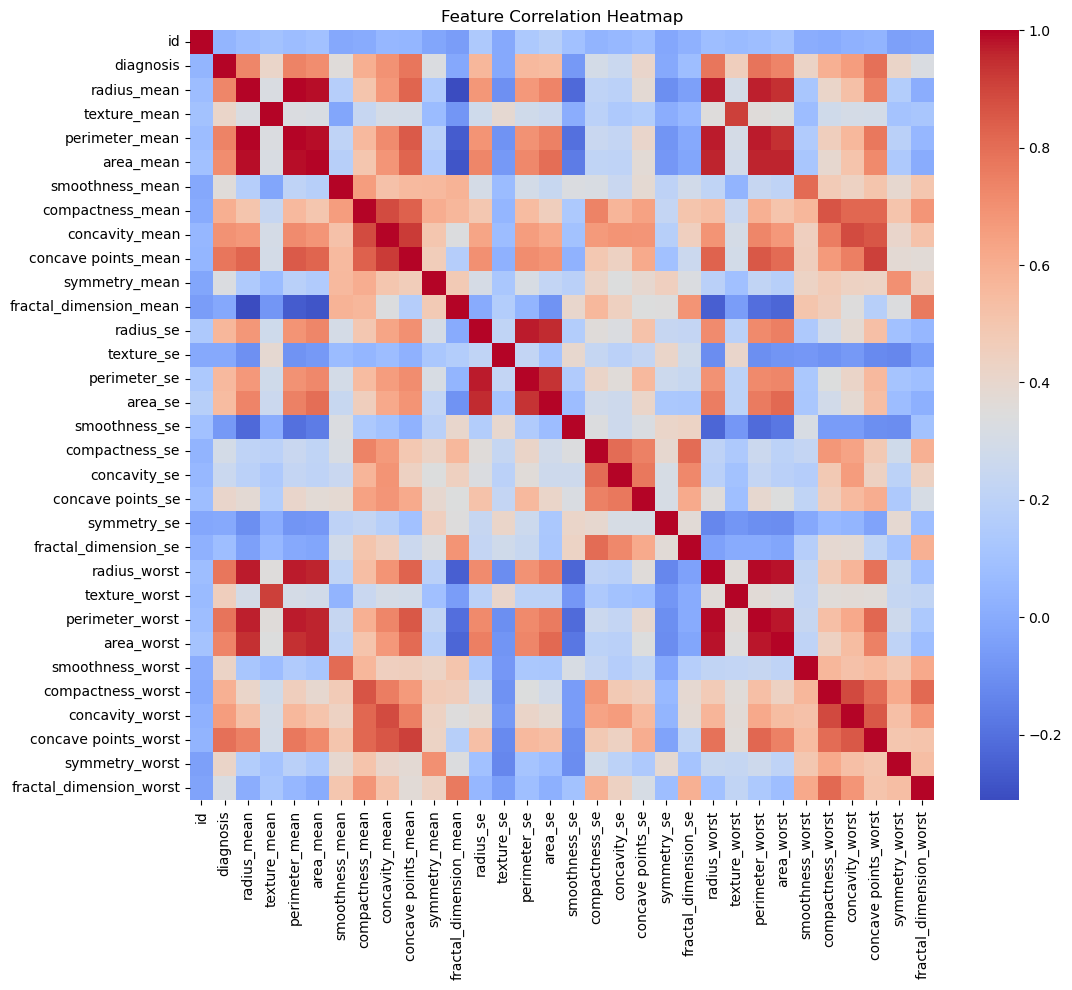

In [15]:
corr_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [16]:
correlation_target = corr_matrix['diagnosis'].abs().sort_values(ascending=False)
print(correlation_target)

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
smoothness_se              0

In [17]:
important_features = correlation_target[correlation_target > 0.5].index.tolist()


df_selected = df[important_features]


In [18]:
df_selected.head()

,diagnosis,concave points_worst,perimeter_worst,concave points_mean,radius_worst,perimeter_mean,area_worst,radius_mean,area_mean,concavity_mean,concavity_worst,compactness_mean,compactness_worst,radius_se,perimeter_se,area_se
0,1,0.2654,184.60,0.14710,25.38,122.80,2019.0,17.99,1001.0,0.3001,0.7119,0.27760,0.6656,1.0950,8.589,153.40
1,1,0.1860,158.80,0.07017,24.99,132.90,1956.0,20.57,1326.0,0.0869,0.2416,0.07864,0.1866,0.5435,3.398,74.08
2,1,0.2430,152.50,0.12790,23.57,130.00,1709.0,19.69,1203.0,0.1974,0.4504,0.15990,0.4245,0.7456,4.585,94.03
3,1,0.2575,98.87,0.10520,14.91,77.58,567.7,11.42,386.1,0.2414,0.6869,0.28390,0.8663,0.4956,3.445,27.23
4,1,0.1625,152.20,0.10430,22.54,135.10,1575.0,20.29,1297.0,0.1980,0.4000,0.13280,0.2050,0.7572,5.438,94.44


In [19]:
from imblearn.over_sampling import SMOTE
from collections import Counter
X = df_selected.drop(columns=['diagnosis'])
Y=df_selected['diagnosis']


In [20]:
smote=SMOTE(sampling_strategy='auto',random_state=42)
X_resampled,Y_resampled=smote.fit_resample(X,Y)

In [21]:
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['diagnosis'] = Y_resampled

In [22]:
print("Class distribution before SMOTE:", Counter(Y))
print("Class distribution after SMOTE:", Counter(Y_resampled))

Class distribution before SMOTE: Counter({0: 357, 1: 212})
Class distribution after SMOTE: Counter({1: 357, 0: 357})


In [23]:
X_train,X_test,y_train,y_test=train_test_split(X_resampled,Y_resampled,test_size=0.2,random_state=42)


In [24]:
tpot = TPOTClassifier(generations=5, population_size=20, random_state=42)

In [25]:
tpot.fit(X_train,y_train)

C:\Users\Aarsh Sharma\anaconda3\Lib\site-packages\tpot\tpot_estimator\estimator.py:456: UserWarning: Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.
  warnings.warn("Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.")
Generation: 100%|███████████████████████████████████████████████████████████████████████| 5/5 [14:47<00:00, 177.51s/it]


TPOTClassifier(random_state=42,
               search_space=<tpot.search_spaces.pipelines.sequential.SequentialPipeline object at 0x000001E31F765210>)

In [26]:
y_pred = tpot.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Best AutoML Model accuracy:", accuracy)

Best AutoML Model accuracy: 0.958041958041958


In [27]:
print(f"The classification report for TPOT model is:\n", classification_report(y_test,y_pred))

The classification report for TPOT model is:
               precision    recall  f1-score   support

           0       0.97      0.94      0.96        69
           1       0.95      0.97      0.96        74

    accuracy                           0.96       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143



In [28]:
tpot_prob = tpot.predict_proba(X_test)[:, 1]
tpot_auc = roc_auc_score(y_test, tpot_prob)

In [29]:
print(f"The ROC AUC SCORE OF TPOT IS:",tpot_auc )

The ROC AUC SCORE OF TPOT IS: 0.9929494712103408


In [30]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
log_reg=LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

In [32]:
log_reg_pred = log_reg.predict(X_test)
log_reg_acc = accuracy_score(y_test, log_reg_pred)

In [33]:
print(f"Logistic Regression Accuracy: {log_reg_acc:.4f}")

Logistic Regression Accuracy: 0.9371


In [34]:
print(f"The classification report for Logistic regression model is:\n", classification_report(y_test,log_reg_pred))

The classification report for Logistic regression model is:
               precision    recall  f1-score   support

           0       0.95      0.91      0.93        69
           1       0.92      0.96      0.94        74

    accuracy                           0.94       143
   macro avg       0.94      0.94      0.94       143
weighted avg       0.94      0.94      0.94       143



In [35]:
log_reg_prob = log_reg.predict_proba(X_test)[:, 1]
log_reg_auc = roc_auc_score(y_test, log_reg_prob)

In [36]:
print(f"The ROC AUC SCORE OF LOGISTIC REGRESSION IS:",log_reg_auc)

The ROC AUC SCORE OF LOGISTIC REGRESSION IS: 0.9890325107716412


In [37]:
svm = SVC(kernel='rbf',probability=True, C=1.0)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

In [38]:
print(f"SVM Accuracy: {svm_acc:.4f}")

SVM Accuracy: 0.9441


In [39]:
print(f"The classification report for SVM  model is:\n", classification_report(y_test,svm_pred))

The classification report for SVM  model is:
               precision    recall  f1-score   support

           0       0.97      0.91      0.94        69
           1       0.92      0.97      0.95        74

    accuracy                           0.94       143
   macro avg       0.95      0.94      0.94       143
weighted avg       0.95      0.94      0.94       143



In [40]:
svm_prob = svm.predict_proba(X_test)[:, 1]
svm_auc = roc_auc_score(y_test, svm_prob)

In [41]:
print(f"The ROC AUC SCORE OF SVM IS:",svm_auc)

The ROC AUC SCORE OF SVM IS: 0.9904034469251861


In [42]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

In [43]:
print(f"Random Forest Accuracy: {rf_acc:.4f}")

Random Forest Accuracy: 0.9510


In [44]:
print(f"The classification report for Random Forest model is:\n", classification_report(y_test,rf_pred))

The classification report for Random Forest model is:
               precision    recall  f1-score   support

           0       0.96      0.94      0.95        69
           1       0.95      0.96      0.95        74

    accuracy                           0.95       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143



In [45]:
rf_prob = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_prob)

In [46]:
print(f"The ROC AUC SCORE OF RANDOM FOREST IS:",rf_auc)

The ROC AUC SCORE OF RANDOM FOREST IS: 0.990207598903251


In [47]:

model_accuracies = {
    'Logistic Regression': log_reg_acc,
    'Random Forest': rf_acc,
    'SVM': svm_acc,
    'TPOT': accuracy 
}


best_model_name = max(model_accuracies, key=model_accuracies.get)

print(f"\nBest Model: {best_model_name} with accuracy: {model_accuracies[best_model_name]:.4f}")



Best Model: TPOT with accuracy: 0.9580


In [48]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

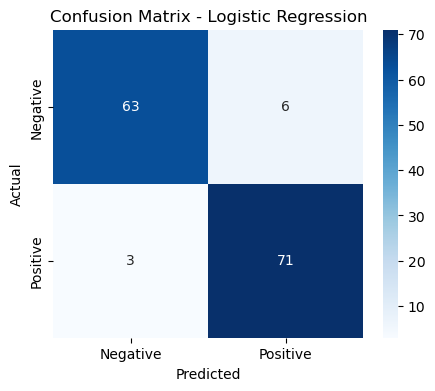

In [49]:

plot_confusion_matrix(y_test, log_reg_pred, "Logistic Regression")





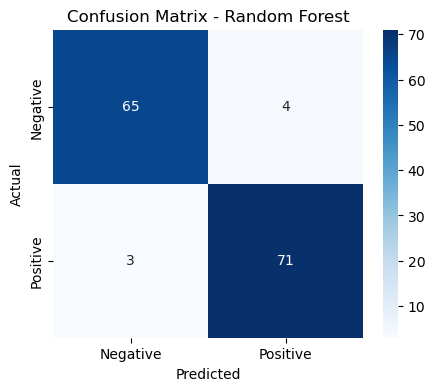

In [50]:
plot_confusion_matrix(y_test,rf_pred , "Random Forest")




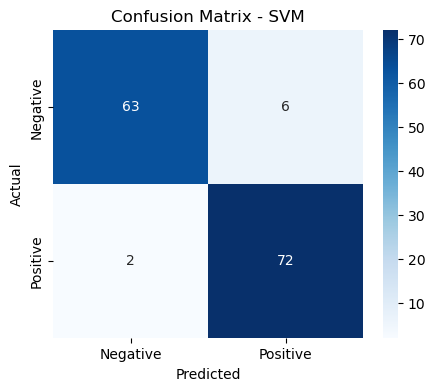

In [51]:
plot_confusion_matrix(y_test, svm_pred, "SVM")




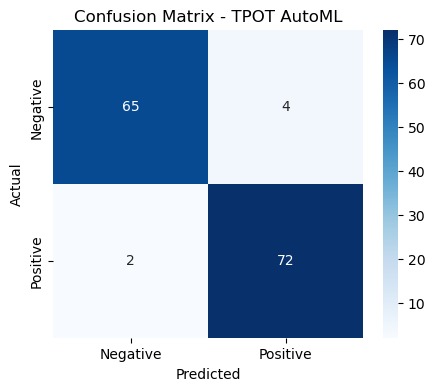

In [52]:
plot_confusion_matrix(y_test, y_pred, "TPOT AutoML")